# Business Sales Performance Analytics

Future Interns - Data Science & Analytics Internship

Prepared by: Vanshika Sharma

# Data Loading

# Business KPI Analysis

# Import Required Libraries

In [2]:
import pandas as pd
import numpy as np

# Load Dataset

In [3]:
df = pd.read_csv("../data/superstore.csv")

df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2017-152156,11/8/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2.0,0.00,41.9136
1,2,CA-2017-152156,11/8/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3.0,0.00,219.5820
2,3,CA-2017-138688,6/12/2017,6/16/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2.0,0.00,6.8714
3,4,US-2016-108966,10/11/2016,10/18/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5.0,0.45,-383.0310
4,5,US-2016-108966,10/11/2016,10/18/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2.0,0.20,2.5164


# Dataset Information

In [4]:
print("Dataset Shape:", df.shape)

df.info()

Dataset Shape: (10800, 21)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10800 entries, 0 to 10799
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         10800 non-null  object 
 1   Order ID       10800 non-null  object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal Code    9983 non-null   float64
 12  Region         9994 non-null   object 
 13  Product ID     9994 non-null   object 
 14  Category       9994 non-null   object 
 15  Sub-Category   9994 non-null   object 
 16  Product Name   9994 non-null   object 
 17  Sales          9994 non

# Missing Value Analysis

In [5]:
df.isnull().sum()

Row ID             0
Order ID           0
Order Date       806
Ship Date        806
Ship Mode        806
Customer ID      806
Customer Name    806
Segment          806
Country          806
City             806
State            806
Postal Code      817
Region           806
Product ID       806
Category         806
Sub-Category     806
Product Name     806
Sales            806
Quantity         806
Discount         806
Profit           806
dtype: int64

# Duplicate Value Analysis

In [6]:
print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 504


# Data Cleaning

In [7]:
df_clean = df.dropna()

df_clean = df_clean.drop_duplicates()

print("Original Shape:", df.shape)

print("Cleaned Shape:", df_clean.shape)

Original Shape: (10800, 21)
Cleaned Shape: (9983, 21)


In [8]:
print("Missing Values:", df_clean.isnull().sum().sum())

print("Duplicate Rows:", df_clean.duplicated().sum())

Missing Values: 0
Duplicate Rows: 0


In [9]:
df_clean.to_csv("../data/superstore_cleaned.csv", index=False)

# Business KPI Analysis

In [10]:
print("Total Sales:", round(df_clean["Sales"].sum(), 2))

print("Total Profit:", round(df_clean["Profit"].sum(), 2))

print("Total Orders:", df_clean["Order ID"].nunique())

Total Sales: 2288271.49
Total Profit: 284152.04
Total Orders: 5003


# Category Performance Analysis

In [11]:
category_sales = df_clean.groupby("Category")["Sales"].sum().sort_values(ascending=False)

print(category_sales)

Category
Technology         834554.2730
Furniture          736879.6953
Office Supplies    716837.5220
Name: Sales, dtype: float64


In [12]:
category_profit = df_clean.groupby("Category")["Profit"].sum().sort_values(ascending=False)

print(category_profit)

Category
Technology         145007.6618
Office Supplies    121885.0358
Furniture           17259.3458
Name: Profit, dtype: float64


# Regional Performance Analysis

In [13]:
region_sales = df_clean.groupby("Region")["Sales"].sum().sort_values(ascending=False)

print(region_sales)

Region
West       725457.8245
East       669851.8700
Central    501239.8908
South      391721.9050
Name: Sales, dtype: float64


In [14]:
region_profit = df_clean.groupby("Region")["Profit"].sum().sort_values(ascending=False)

print(region_profit)

Region
West       108418.4489
East        89277.8017
South       46749.4303
Central     39706.3625
Name: Profit, dtype: float64


# Top 10 Products Analysis

In [15]:
top_products = df_clean.groupby("Product Name")["Sales"].sum().sort_values(ascending=False).head(10)

print(top_products)

Product Name
Canon imageCLASS 2200 Advanced Copier                                          61599.824
Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind    27453.384
Cisco TelePresence System EX90 Videoconferencing Unit                          22638.480
HON 5400 Series Task Chairs for Big and Tall                                   21870.576
GBC DocuBind TL300 Electric Binding System                                     19823.479
GBC Ibimaster 500 Manual ProClick Binding System                               19024.500
Hewlett Packard LaserJet 3310 Copier                                           18839.686
HP Designjet T520 Inkjet Large Format Printer - 24" Color                      18374.895
GBC DocuBind P400 Electric Binding System                                      17965.068
High Speed Automatic Electric Letter Opener                                    17030.312
Name: Sales, dtype: float64


# Category Sales Visualization

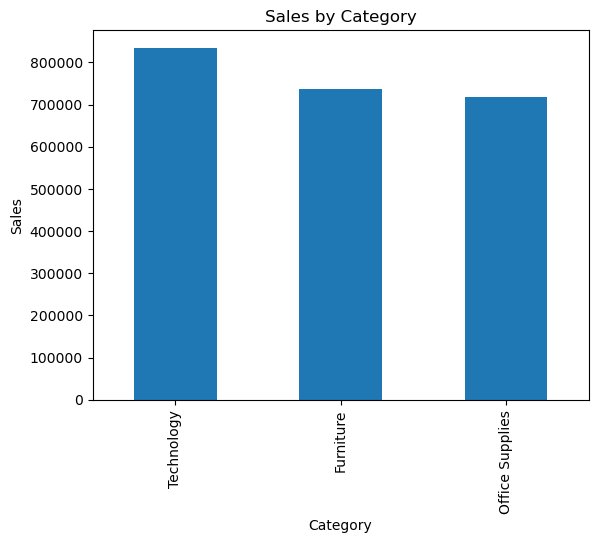

In [16]:
import matplotlib.pyplot as plt

category_sales.plot(kind="bar")

plt.title("Sales by Category")
plt.ylabel("Sales")
plt.show()

# Regional Sales Visualization

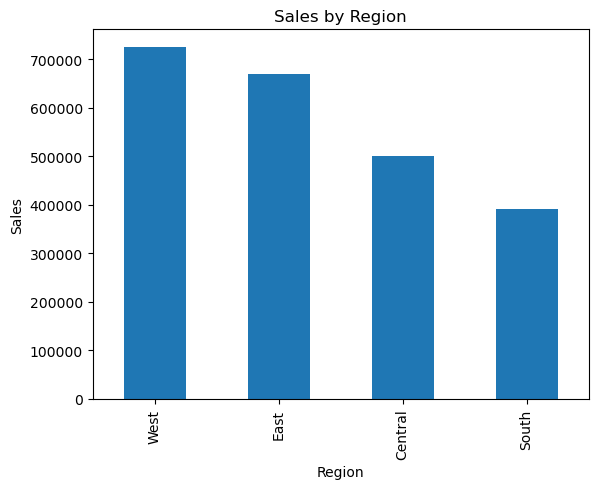

In [17]:
region_sales.plot(kind="bar")

plt.title("Sales by Region")
plt.ylabel("Sales")
plt.show()